In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Missing Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Missing Values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Basic Stats:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


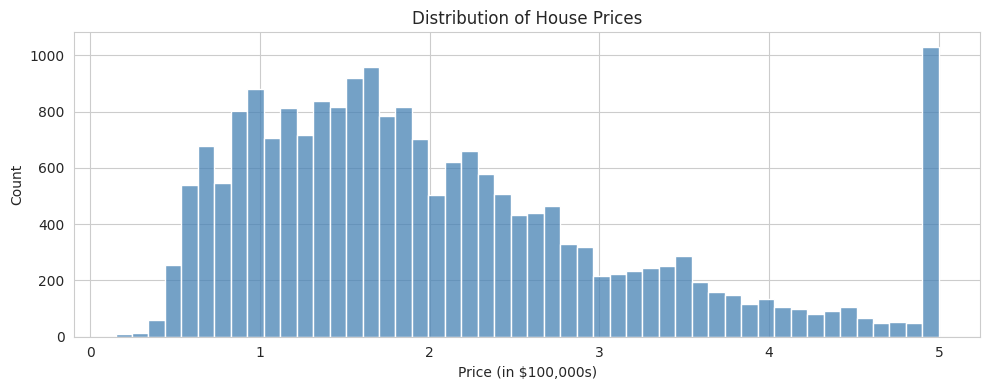

In [5]:
plt.figure(figsize=(10,4))
sns.histplot(df['Price'], bins=50, color='steelblue')
plt.title("Distribution of House Prices")
plt.xlabel("Price (in $100,000s)")
plt.tight_layout()
plt.show()


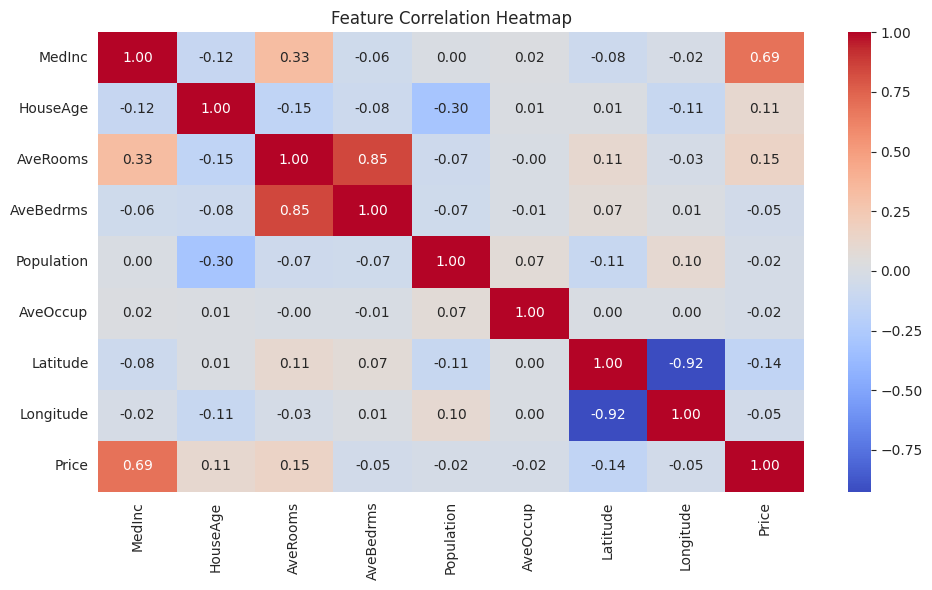

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [8]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("All 3 models trained!")

All 3 models trained!


In [9]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred)
]
rmse_scores = [
    np.sqrt(mean_squared_error(y_test, lr_pred)),
    np.sqrt(mean_squared_error(y_test, dt_pred)),
    np.sqrt(mean_squared_error(y_test, rf_pred))
]

results = pd.DataFrame({
    'Model': models,
    'R2 Score': r2_scores,
    'RMSE': rmse_scores
})
print(results)

               Model  R2 Score      RMSE
0  Linear Regression  0.575788  0.745581
1      Decision Tree  0.622076  0.703729
2      Random Forest  0.805123  0.505340


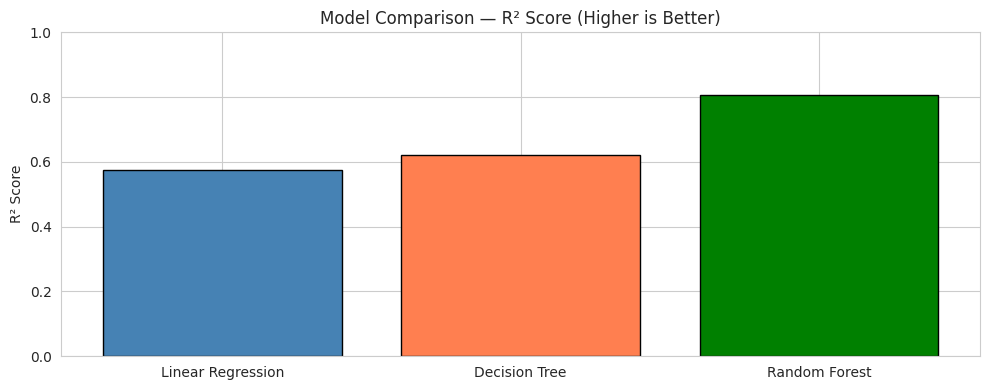

In [10]:
plt.figure(figsize=(10,4))
plt.bar(models, r2_scores, color=['steelblue','coral','green'], edgecolor='black')
plt.title("Model Comparison — R² Score (Higher is Better)")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

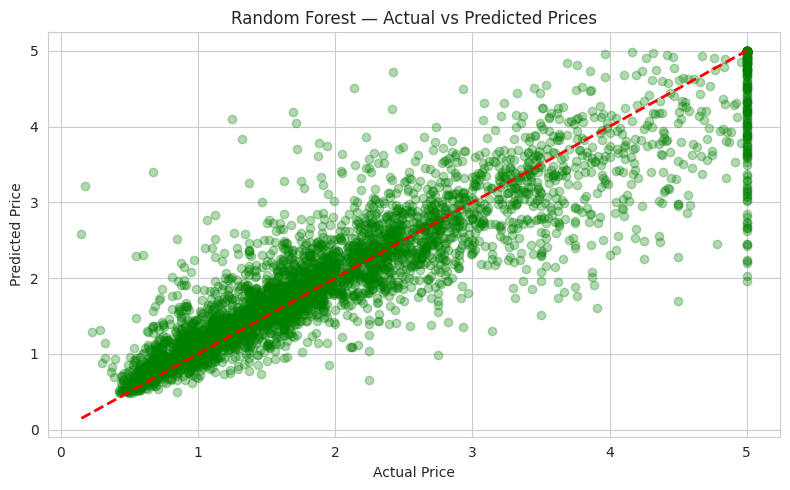

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title("Random Forest — Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.show()

## House Price Prediction — Key Findings

- Trained 3 ML models: Linear Regression, Decision Tree, Random Forest
- Random Forest performed best with highest R² score
- MedInc (Median Income) is the strongest predictor of house price
- Model successfully learned patterns from 16,512 training samples

In [13]:
best = results.loc[results['R2 Score'].idxmax()]
print("=" * 40)
print("House Price Prediction Complete!")
print("=" * 40)
print(f"Best Model: {best['Model']}")
print(f"R² Score: {best['R2 Score']:.4f}")
print(f"RMSE: {best['RMSE']:.4f}")

House Price Prediction Complete!
Best Model: Random Forest
R² Score: 0.8051
RMSE: 0.5053
